# 7 · Path smoothing and tracking

Shorten a planner's path by shortcutting, then make the bicycle of chapter 1 follow it with pure pursuit and
Stanley — and see where each of them leaves the path.

In [1]:
# Installs the module when it is missing (e.g. on Colab); a local `pip install -e .` is used as is.
import importlib.util

if importlib.util.find_spec("motion_planning") is None:
    %pip install -q git+https://github.com/Rudip1/learn-motion-planning

## Recap

Theory: [`1_theory/07_smoothing_tracking.md`](../../1_theory/07_smoothing_tracking.md).

- Shortcutting replaces stretches of a path by collision-free straight segments: greedy between vertices,
  random between any two points; neither lengthens the path.
- Cross-track error $e$ (positive left) and heading error $\theta_e$ come from projecting onto the path (7.1).
- Pure pursuit steers onto the arc through a target $L_d$ ahead: $\kappa = 2 y_v / L_d^2$ (7.3).
- Stanley: $\gamma = \theta_e - \arctan(k e / (k_s + v))$ at the front axle (7.5); small errors decay like
  $e^{-kt}$ (7.6).

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import motion_planning as mp
from motion_planning import maps
from motion_planning.plotting import INK, SERIES, show_grid, use_style

use_style()
rng = np.random.default_rng(7)

rooms = maps.rooms()
inflated = mp.inflate(rooms, 0.3)
problem = mp.problem_from_grid(inflated, [2.0, 2.8], [8.0, 7.0])
raw = mp.rrt(problem, mp.RrtOptions(step=0.3, seed=2)).path
print(f"RRT path: {len(raw)} points, {mp.path_length(raw):.2f} m")

RRT path: 48 points, 13.69 m


## Shortcutting

### ✏️ Exercise 1 — greedy shortcutting

Implement the algorithm of section 7.1 with `problem.motion_valid`. Your result should equal `mp.shortcut_greedy`.

In [3]:
def shortcut_greedy(path, motion_valid):
    out, i, n = [path[0]], 0, len(path)
    while i < n - 1:
        j = n - 1
        while j > i + 1 and not motion_valid(path[i], path[j]):
            j -= 1
        out.append(path[j])
        i = j
    return np.array(out)

In [4]:
mine = shortcut_greedy(raw, problem.motion_valid)
assert np.allclose(mine, mp.shortcut_greedy(raw, problem.motion_valid))
print(f"✓ greedy: {len(mine)} points, {mp.path_length(mine):.2f} m")

✓ greedy: 6 points, 11.27 m


Random shortcuts can cut between points *inside* segments; a greedy pass afterwards removes leftover kinks.
Over 20 seeds:

In [5]:
lengths = [mp.path_length(mp.shortcut_greedy(mp.shortcut_random(raw, problem.motion_valid, 300, s), problem.motion_valid))
           for s in range(20)]
print(f"random + greedy: median {np.median(lengths):.2f} m (best {min(lengths):.2f}) vs greedy alone {mp.path_length(mine):.2f} m")
path = mp.shortcut_greedy(mp.shortcut_random(raw, problem.motion_valid, 300, int(np.argmin(lengths))), problem.motion_valid)
print("turning angles at the corners [deg]:", np.degrees(mp.turning_angles(path)).round(0))

random + greedy: median 10.21 m (best 10.07) vs greedy alone 11.27 m
turning angles at the corners [deg]: [16. 19. 12. 14. 44. 10. 81.]


### ✏️ Exercise 2 — projection onto a polyline

Implement eq. (7.1): return `(s, lateral)` — the arc length of the closest point of the polyline `P` to `p`, and
the signed distance, positive to the left. Compare with `mp.Path2D.project`.

In [6]:
def project(P, p):
    best = (np.inf, 0.0, 0.0)
    s0 = 0.0
    for a, b in zip(P[:-1], P[1:]):
        ab = b - a
        L = np.linalg.norm(ab)
        t = np.clip(np.dot(p - a, ab) / L**2, 0.0, 1.0)
        c = a + t * ab
        d = np.linalg.norm(p - c)
        if d < best[0] - 1e-12:
            lateral = (ab[0] * (p - c)[1] - ab[1] * (p - c)[0]) / L
            best = (d, s0 + t * L, lateral)
        s0 += L
    return best[1], best[2]

In [7]:
P2 = mp.Path2D(path)
for _ in range(300):
    p = rng.uniform([0, 0], [10, 8])
    ref = P2.project(p)
    assert np.allclose(project(path, p), (ref.s, ref.lateral))
print("✓ projection")

✓ projection


## The two trackers

### ✏️ Exercise 3 — pure pursuit and Stanley laws

Implement eq. (7.3) (curvature from the rear-axle pose `q` to `target`) and eq. (7.5).

In [8]:
def pp_curvature(q, target):
    dx, dy = target[0] - q[0], target[1] - q[1]
    y_v = -np.sin(q[2]) * dx + np.cos(q[2]) * dy
    return 2 * y_v / (dx**2 + dy**2)


def stanley(theta_e, e, v, k, k_s):
    return theta_e - np.arctan(k * e / (k_s + abs(v)))

In [9]:
assert np.isclose(pp_curvature([0, 0, 0], [3, 1]), 0.2)
for _ in range(200):
    q, t = np.r_[rng.uniform(-3, 3, 2), rng.uniform(-np.pi, np.pi)], rng.uniform(-3, 3, 2)
    assert np.isclose(pp_curvature(q, t), mp.pure_pursuit_curvature(q, t))
    args = rng.uniform(-1, 1), rng.uniform(-2, 2), rng.uniform(0, 3), rng.uniform(0.1, 3), 0.1
    assert np.isclose(stanley(*args), mp.stanley_steering(*args))
print("✓ tracking laws")

✓ tracking laws


Track the smoothed path with a 0.5 m-wheelbase bicycle at 1 m/s. Then check the *executed* trajectory against the
real (not inflated) map: the planner left 0.3 m of margin; did the tracker stay inside it?

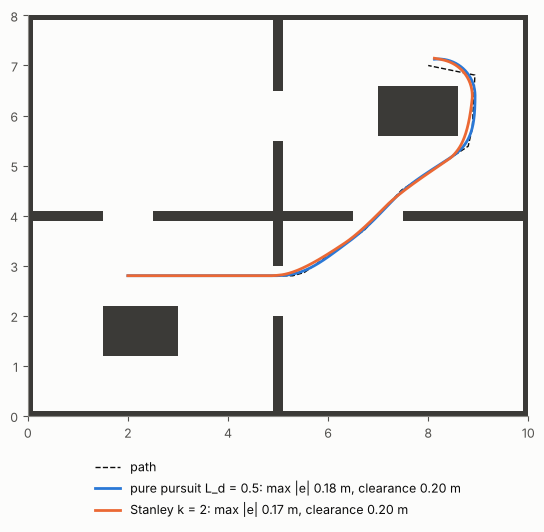

In [10]:
bike = mp.KinematicBicycle(0.5, 0.6)
start = np.r_[path[0], np.arctan2(path[1, 1] - path[0, 1], path[1, 0] - path[0, 0])]
D = mp.distance_transform(rooms)


def clearance(states):
    return min(D[c.y, c.x] for c in (rooms.world_to_cell(s[:2]) for s in states))


fig, ax = plt.subplots(figsize=(6.5, 5.2))
show_grid(ax, rooms)
ax.plot(path[:, 0], path[:, 1], "--", color=INK, lw=1, label="path")
for (name, opt), c in zip([("pure pursuit L_d = 0.5", mp.TrackingOptions(lookahead=0.5)),
                           ("Stanley k = 2", mp.TrackingOptions(mp.TrackingController.Stanley, stanley_gain=2.0))],
                          SERIES):
    r = mp.track_path(bike, path, start, opt)
    ax.plot(r.states[:, 0], r.states[:, 1], color=c, lw=2,
            label=f"{name}: max |e| {np.abs(r.cross_track).max():.2f} m, clearance {clearance(r.states):.2f} m")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.show()

### 🔨 Break it — the lookahead

Sweep $L_d$. Short lookaheads follow the corners but react violently to a 1 m initial offset (watch the
steering); long ones cut the corners — at some point through the planning margin and into a wall.

In [11]:
for Ld in [0.15, 0.5, 1.0, 2.0, 3.0]:
    r = mp.track_path(bike, path, start + [0, 0.8, 0], mp.TrackingOptions(lookahead=Ld))
    steer = np.array(r.steering)
    print(f"L_d = {Ld:4.2f} m: max |e| after 3 s {np.abs(r.cross_track[150:]).max():.2f} m, "
          f"steering reversals {int(np.sum(np.diff(np.sign(steer[np.abs(steer) > 0.01])) != 0))}, "
          f"min clearance {clearance(r.states):.2f} m, reached end {r.reached_end}")

L_d = 0.15 m: max |e| after 3 s 0.52 m, steering reversals 11, min clearance 0.28 m, reached end True
L_d = 0.50 m: max |e| after 3 s 0.18 m, steering reversals 5, min clearance 0.20 m, reached end True
L_d = 1.00 m: max |e| after 3 s 0.17 m, steering reversals 3, min clearance 0.14 m, reached end True
L_d = 2.00 m: max |e| after 3 s 0.38 m, steering reversals 1, min clearance 0.00 m, reached end True
L_d = 3.00 m: max |e| after 3 s 0.69 m, steering reversals 1, min clearance 0.00 m, reached end True


### 🔨 Break it — a slow steering actuator

The same Stanley controller on a straight line, with the steering rate limited (1.17). The law assumes it can set
$\gamma$ instantly; a lagging actuator turns convergence into overshoot.

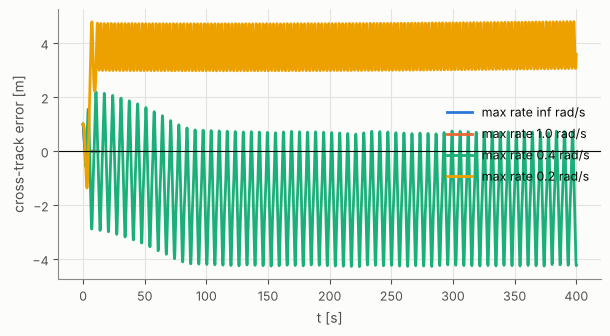

In [12]:
line = np.array([[0.0, 0.0], [25.0, 0.0]])
fig, ax = plt.subplots(figsize=(7, 3.5))
for rate, c in zip([np.inf, 1.0, 0.4, 0.2], SERIES):
    r = mp.track_path(bike, line, np.array([0.0, 1.0, 0.0]),
                      mp.TrackingOptions(mp.TrackingController.Stanley, speed=2.0, stanley_gain=2.0, steering_rate=rate))
    ax.plot(np.arange(len(r.cross_track)) * 0.02, r.cross_track, color=c, label=f"max rate {rate} rad/s")
ax.axhline(0, color=INK, lw=0.8)
ax.set_xlabel("t [s]")
ax.set_ylabel("cross-track error [m]")
ax.legend()
plt.show()

### ✏️ Exercise 4 — check the Stanley decay rate

Eq. (7.6) predicts $\dot e \approx -k e$ for small errors. Start 5 cm off a straight path, simulate Stanley with
$k = 1.5$, and estimate the decay rate as the slope of $\log |e(t)|$ between $t = 0.5$ s and $t = 2$ s
(the cross-track error recorded here is the rear axle's, which follows the front with a lag). Return the rate.

In [13]:
def decay_rate(k, speed=2.0):
    r = mp.track_path(bike, line, np.array([0.0, 0.05, 0.0]),
                      mp.TrackingOptions(mp.TrackingController.Stanley, speed=speed, stanley_gain=k, softening=0.0))
    e = np.abs(np.array(r.cross_track))
    t = np.arange(len(e)) * 0.02
    sel = (t >= 0.5) & (t <= 2.0)
    return -np.polyfit(t[sel], np.log(e[sel]), 1)[0]

In [14]:
for k in [0.5, 1.5, 3.0]:
    print(f"k = {k}: measured decay rate {decay_rate(k):.2f} 1/s")
assert abs(decay_rate(1.5) - 1.5) < 0.3
print("✓ Stanley decays at about k")

k = 0.5: measured decay rate 0.49 1/s
k = 1.5: measured decay rate 1.44 1/s
k = 3.0: measured decay rate 2.66 1/s
✓ Stanley decays at about k


### 🔨 Break it — a sign error

Flip the sign of the cross-track term (steer *towards* positive $e$): the controller pushes the car away from the
path until the steering saturates and it circles.

In [15]:
def stanley_wrong(theta_e, e, v, k, k_s):
    return theta_e + np.arctan(k * e / (k_s + abs(v)))


q = np.array([0.0, 0.3, 0.0])
traj = [q]
for _ in range(400):
    front = q[:2] + 0.5 * np.array([np.cos(q[2]), np.sin(q[2])])
    pr = mp.Path2D(line).project(front)
    g = np.clip(stanley_wrong(mp.angle_difference(pr.heading, q[2]), pr.lateral, 1.0, 2.0, 0.1), -0.6, 0.6)
    q = bike.step(q, np.array([1.0, g]), 0.02)
    traj.append(q)
traj = np.array(traj)
print(f"after 8 s the car is {abs(traj[-1, 1]):.2f} m off the path")

after 8 s the car is 7.50 m off the path


## What to remember

- Shortcut the planner's path (random, then greedy), re-checking every new segment; plan with a margin.
- Errors are defined by projection (7.1); fix the sign convention once.
- Pure pursuit: one gain, the lookahead — short reacts and oscillates, long smooths and cuts corners.
- Stanley: heading plus $\arctan(ke/v)$ at the front axle; small errors decay like $e^{-kt}$.
- Actuator limits and polyline corners are where trackers fail; verify the executed trajectory, not the plan.